QUARTA LISTA DE EXERCÍCIOS - CLASSIFICAÇÃO DE DADOS

In [22]:
import pandas as pd 
import numpy as np
from sklearn.datasets import load_diabetes

In [23]:
dataset = load_diabetes()
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df["target"] = dataset.target
display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


<em>QUESTÃO 1</em> - Carregue a base de dados de diabetes e exiba:<br>
-Dimensão X e y<br>
-Nome das features<br>

In [24]:
print(f"Shape: {df.shape}")

features = dataset.feature_names
print(f"Nomes das features: {features}")

Shape: (442, 11)
Nomes das features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


<em>QUESTÃO 2</em> - Transforme o problema de regressão em classificação binária utilizando a mediana do target:<br>
• Classe 0: abaixo da mediana<br>
• Classe 1: acima da mediana<br>
Mostre a distribuição das classes.<br>

In [25]:
mediana_target = np.median(dataset.target)
print(f"Mediana do target: {mediana_target}")

df["classificacao_binaria"] = df["target"].apply(lambda x: 0 if x < mediana_target else 1)
target="classificacao_binaria"
display(df.head())

print("Distribuição das classes:")
display(df["classificacao_binaria"].value_counts())

Mediana do target: 140.5


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,classificacao_binaria
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,0


Distribuição das classes:


classificacao_binaria
1    221
0    221
Name: count, dtype: int64

<em>QUESTÃO 3</em> - Divisão dos Dados:<br>
Divida os dados em conjunto de treino e teste (75% / 25%).

In [26]:
from sklearn.model_selection import train_test_split

df_treino, df_teste = train_test_split(df, test_size=0.25, random_state=42)

print("Dataset de treino:")
display(df_treino)

print("Dataset de teste:")
display(df_teste)

X_treino = df_treino[features]
y_treino = df_treino[target]
X_teste = df_teste[features]
y_teste = df_teste[target]


Dataset de treino:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,classificacao_binaria
16,-0.005515,-0.044642,0.042296,0.049415,0.024574,-0.023861,0.074412,-0.039493,0.052277,0.027917,166.0,1
408,0.063504,-0.044642,-0.050396,0.107944,0.031454,0.019354,-0.017629,0.023608,0.058038,0.040343,189.0,1
432,0.009016,-0.044642,0.055229,-0.005670,0.057597,0.044719,-0.002903,0.023239,0.055686,0.106617,173.0,1
316,0.016281,0.050680,0.014272,0.001215,0.001183,-0.021355,-0.032356,0.034309,0.074966,0.040343,220.0,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.096328,-0.044642,-0.076264,-0.043542,-0.045599,-0.034821,0.008142,-0.039493,-0.059471,-0.083920,134.0,0
270,0.005383,0.050680,0.030440,0.083844,-0.037344,-0.047347,0.015505,-0.039493,0.008641,0.015491,202.0,1
348,0.030811,-0.044642,-0.020218,-0.005670,-0.004321,-0.029497,0.078093,-0.039493,-0.010903,-0.001078,148.0,1
435,-0.012780,-0.044642,-0.023451,-0.040099,-0.016704,0.004636,-0.017629,-0.002592,-0.038460,-0.038357,64.0,0


Dataset de teste:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,classificacao_binaria
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220,219.0,1
211,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788,70.0,0
72,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646,202.0,1
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,230.0,1
73,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362,111.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
45,0.027178,0.050680,-0.035307,0.032201,-0.011201,0.001504,-0.010266,-0.002592,-0.014960,-0.050783,53.0,0
153,0.041708,0.050680,-0.043929,0.063187,-0.004321,0.016222,-0.013948,-0.002592,-0.034522,0.011349,71.0,0
239,0.023546,-0.044642,0.019662,-0.012556,0.083740,0.038769,0.063367,-0.002592,0.066051,0.048628,262.0,1
380,0.016281,-0.044642,0.026128,0.058608,-0.060735,-0.044215,-0.013948,-0.033958,-0.051404,-0.025930,52.0,0


<em>QUESTÃO 4</em> - Aplique normalização nos dados utilizando StandardScaler.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino = pd.DataFrame(scaler.fit_transform(X_treino), columns=features)
X_teste = pd.DataFrame(scaler.fit_transform(X_teste), columns=features)

print("X_treino normalizado:")
display(X_treino)

print("X_teste normalizado:")
display(X_teste)


X_treino normalizado:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,-0.140760,-0.944155,0.847910,1.006118,0.499667,-0.495708,1.595610,-0.836153,1.053499,0.520279
1,1.347042,-0.944155,-1.118412,2.229852,0.642812,0.400279,-0.362375,0.471261,1.173589,0.782398
2,0.172461,-0.944155,1.122280,-0.145632,1.186763,0.926185,-0.049098,0.463615,1.124565,2.180368
3,0.329072,1.059148,0.253440,-0.001664,0.012974,-0.443767,-0.675653,0.692986,1.526449,0.782398
4,-1.941785,-0.944155,-0.295300,-0.793492,0.242006,0.517147,-0.753972,0.692986,0.436706,-0.266079
...,...,...,...,...,...,...,...,...,...,...
326,-2.098396,-0.944155,-1.667152,-0.937461,-0.960412,-0.722951,0.185861,-0.836153,-1.275911,-1.838795
327,0.094156,1.059148,0.596403,1.725961,-0.788638,-0.982657,0.342499,-0.836153,0.143891,0.258160
328,0.642294,-0.944155,-0.478214,-0.145632,-0.101542,-0.612576,1.673929,-0.836153,-0.263504,-0.091333
329,-0.297371,-0.944155,-0.546807,-0.865476,-0.359203,0.095124,-0.362375,-0.071583,-0.837924,-0.877691


X_teste normalizado:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.952321,-0.921954,0.015125,-0.260691,2.753291,2.753477,0.354312,0.813790,0.818774,0.095872
1,1.882091,-0.921954,0.910512,0.552697,-0.506207,-0.362800,-0.020246,-0.814670,-0.377331,-0.258854
2,1.309925,1.084652,0.059894,-0.186746,2.274832,1.074952,1.103429,-0.000440,1.951979,-0.170172
3,1.953611,-0.921954,1.223897,1.785350,1.228205,0.806664,-1.593392,3.175058,2.260133,1.514773
4,0.308635,1.084652,-0.275876,0.035087,0.869361,1.171261,-0.170070,0.813790,0.000867,0.007190
...,...,...,...,...,...,...,...,...,...,...
106,0.594717,1.084652,-0.589261,0.774531,-0.207170,0.036193,-0.244981,-0.000440,-0.212837,-0.879623
107,0.880800,1.084652,-0.768339,1.440030,-0.057652,0.359516,-0.319893,-0.000440,-0.638656,0.450597
108,0.523197,-0.921954,0.552357,-0.186746,1.856181,0.854818,1.253252,-0.000440,1.550565,1.248729
109,0.380155,-0.921954,0.686665,1.341684,-1.283701,-0.968170,-0.319893,-0.692536,-1.006139,-0.347535


<em>QUESTÃO 5</em> - Classificação com KNN <br>
Treine um modelo KNN:<br>
• Utilize K = 5<br>
• Faça previsões no conjunto de teste<br>

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=1)

knn.fit(X_treino, y_treino)
predicoes_knn = knn.predict(X_teste)
print(f"Previsão: {predicoes_knn}")

Previsão: [0 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 1 0 1 1 1 0
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 0
 0 1 1 1 1 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 0]


<em>QUESTÃO 6</em> - Avaliação do KNN<br>
Avalie o modelo utilizando:<br>
• Acurácia<br>
• Matriz de confusão<br>

Acurácia do KNN: 0.7297297297297297
Matriz de confusão KNN:


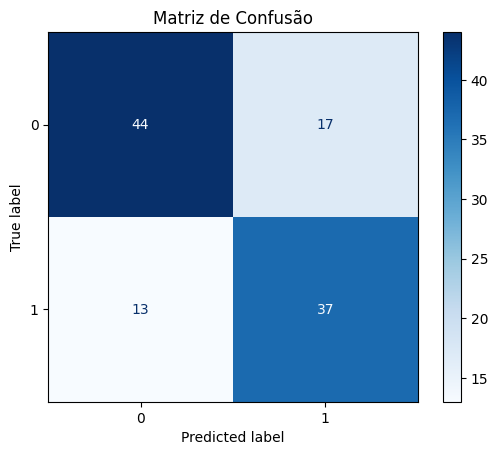

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acuracia_knn = accuracy_score(y_teste, predicoes_knn)
print(F"Acurácia do KNN: {acuracia_knn}")

matriz_de_confusao_knn = confusion_matrix(y_true=y_teste, y_pred=predicoes_knn)

print("Matriz de confusão KNN:")
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_knn)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()


<em>QUESTÃO 7</em> - Classificação com SVM<br>
Treine um modelo SVM:<br>
• Utilize kernel linear<br>
• Faça previsões no conjunto de teste

In [30]:
from sklearn.svm import SVC

svm = SVC(kernel="linear")
svm.fit(X_treino, y_treino)

predicoes_svm = svm.predict(X_teste)
print("Predições do SVM:")
print(predicoes_svm)

Predições do SVM:
[0 1 0 1 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 0 0 1 1 1 0
 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0]


<em>QUESTÃO 8</em> - Avaliação do SVM<br>
Avalie o modelo utilizando:<br>
• Acurácia<br>
• Matriz de confusão

Acurácia do SVM: 0.7747747747747747


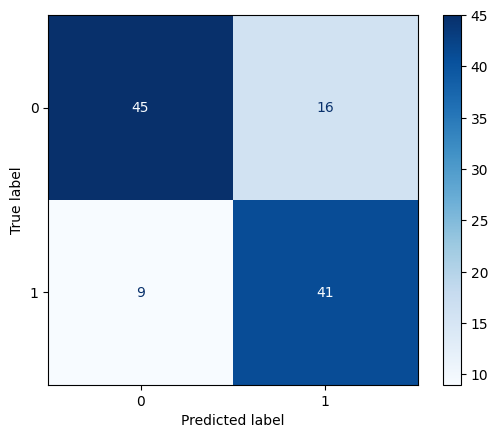

In [31]:
acuracia_svm = accuracy_score(y_true=y_teste, y_pred=predicoes_svm)
print(f"Acurácia do SVM: {acuracia_svm}")

matriz_de_confusao_svm = confusion_matrix(y_true=y_teste, y_pred=predicoes_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_svm)
disp.plot(cmap="Blues")
plt.show()


<em>QUESTÃO 9</em> - Comparação dos Modelos<br>
Compare os resultados dos modelos KNN e SVM:<br>
• Qual modelo teve melhor desempenho?<br>
• Justifique sua resposta

In [32]:
print(f"Acurácia KNN: {acuracia_knn}")
print(f"Acurácia SVM: {acuracia_svm}")

Acurácia KNN: 0.7297297297297297
Acurácia SVM: 0.7747747747747747


Pra mim, o melhor modelo foi o SVM, visto que ele teve uma acurácia maior e, além disso, ao analisar as matrizes de confusão, podemos observar que o SVM se mostrou muito mais eficiente, dando menos resultados enganosos.

<em>QUESTÃO 10</em> - Predição de Novo Exemplo<br>
Crie um novo exemplo com 10 atributos e realize a predição utilizando:<br>
• KNN<br>
• SVM

In [33]:
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=1000, n_features=10, random_state=42)

features_df10 = [f"feature_{i+1}" for i in range(10)]
target = "output"
df10 = pd.DataFrame(X, columns=features_df10)
df10[target] = y

df10_treino, df10_teste = train_test_split(df10, train_size=0.7)

X_treino10, y_treino10 = df10_treino[features_df10], df10_treino[target]
X_teste10, y_teste10 = df10_teste[features_df10], df10_teste[target]

In [34]:
knn.fit(X_treino10, y_treino10)

predicoes10_knn = knn.predict(X_teste10)
acuracia10_knn = accuracy_score(y_true=y_teste10, y_pred=predicoes10_knn)

svm.fit(X_treino10, y_treino10)

predicoes10_svm = svm.predict(X_teste10)
acuracai10_svm = accuracy_score(y_true=y_teste10, y_pred=predicoes10_svm)

print(f"Acurácia KNN: {acuracia10_knn}")
print(f"Acurácia SVM: {acuracai10_svm}")


Acurácia KNN: 0.82
Acurácia SVM: 0.8266666666666667


Matriz de confusão do KNN:


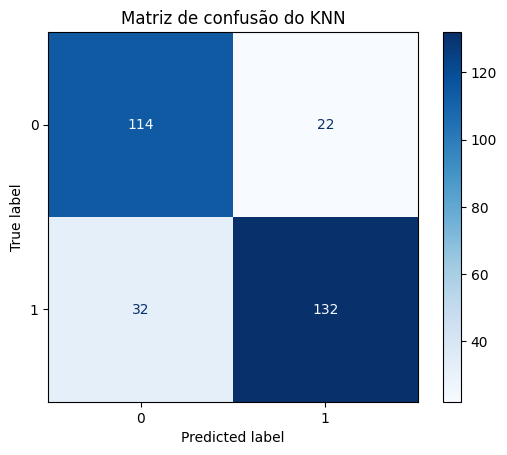

Matriz de confusão do SVM:


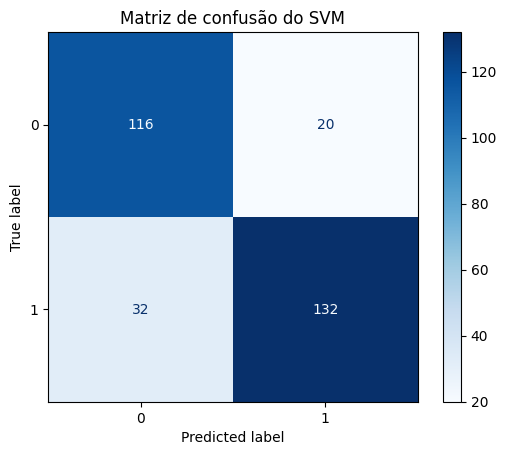

In [35]:
matriz_de_confusao_knn10 = confusion_matrix(y_true=y_teste10, y_pred=predicoes10_knn)
matriz_de_confusao_svm10 = confusion_matrix(y_true=y_teste10, y_pred=predicoes10_svm)

print("Matriz de confusão do KNN:")
disp_knn10 = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_knn10)
disp_knn10.plot(cmap="Blues")
plt.title("Matriz de confusão do KNN")
plt.show()

print("Matriz de confusão do SVM:")
disp_svm10 = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_svm10)
disp_svm10.plot(cmap="Blues")
plt.title("Matriz de confusão do SVM")
plt.show()